In [13]:
# Import required libraries

import pandas as pd
import numpy as np
import pyodbc
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [14]:
# Connect Python to SQL Server

connection = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DILLIBABU\\SQLEXPRESS;'
    'DATABASE=CFB;'
    'Trusted_Connection=yes;'
)

In [15]:
# Read data from SQL table

query = "SELECT * FROM riser"

df = pd.read_sql(query, connection)

print(df.head())

   Ug   Gs     z    r/R  Solid_holdup  Particle_velocity  Solid_flux
0   5  100  0.57  0.000         0.007               6.12       77.86
1   5  100  5.84  0.950         0.027              -0.04       -2.05
2   5  100  5.84  0.837         0.032               2.47      138.94
3   5  100  5.84  0.548         0.010               7.17      128.14
4   5  100  7.78  0.000         0.010               7.81      139.78


C:\Users\dilli\AppData\Local\Temp\ipykernel_11960\1841716495.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


In [16]:
# Display dataset size

print("Dataset Shape:")
print(df.shape)

# Display dataset information

print(df.info())

# Display statistical summary

print(df.describe())

Dataset Shape:
(1200, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Ug                 1200 non-null   int64  
 1   Gs                 1200 non-null   int64  
 2   z                  1200 non-null   float64
 3   r/R                1200 non-null   float64
 4   Solid_holdup       1200 non-null   float64
 5   Particle_velocity  1200 non-null   float64
 6   Solid_flux         1200 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 65.8 KB
None
               Ug           Gs            z          r/R  Solid_holdup  \
count  1200.00000  1200.000000  1200.000000  1200.000000   1200.000000   
mean      7.50000   420.000000     4.825000     0.559667      0.106863   
std       1.53361   246.273308     3.261737     0.322552      0.141197   
min       5.00000   100.000000     0.570000     0.000000      0.005000   
25%       7

In [17]:
# Check missing values

print(df.isnull().sum())

Ug                   0
Gs                   0
z                    0
r/R                  0
Solid_holdup         0
Particle_velocity    0
Solid_flux           0
dtype: int64


In [18]:
# Check duplicate rows

print("Duplicate Rows:",
      df.duplicated().sum())

Duplicate Rows: 0


In [19]:
# Remove missing values

df = df.dropna()

# Remove duplicate rows

df = df.drop_duplicates()

# Display final shape

print(df.shape)

(1200, 7)


In [21]:
# Select input variables

X = df[
    [
        'Ug',
        'Gs',
        'z',
        'r/R',
        'Particle_velocity',
        'Solid_flux'
    ]
]

# Select target variable

y = df['Solid_holdup']

In [22]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display training and testing sizes

print(X_train.shape)
print(X_test.shape)

(960, 6)
(240, 6)


In [23]:
# Create and train Random Forest model

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [24]:
# Predict Solid Holdup

rf_pred = rf.predict(X_test)

In [25]:
# Calculate performance metrics

print("MAE:",
      mean_absolute_error(y_test, rf_pred))

print("MSE:",
      mean_squared_error(y_test, rf_pred))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 Score:",
      r2_score(y_test, rf_pred))

MAE: 0.009565854166666632
MSE: 0.0005313854115624987
RMSE: 0.023051798445294865
R2 Score: 0.9726498835008589


In [26]:
# Display feature importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    )
)

             Feature  Importance
4  Particle_velocity    0.633716
1                 Gs    0.246299
5         Solid_flux    0.082364
2                  z    0.021916
0                 Ug    0.011070
3                r/R    0.004635


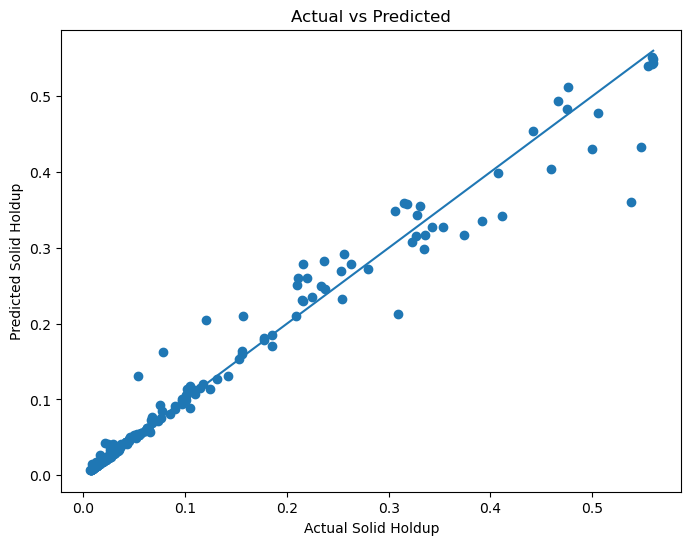

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, rf_pred)

plt.xlabel("Actual Solid Holdup")
plt.ylabel("Predicted Solid Holdup")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [27]:
# Validate and save model

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Average CV Score:",
      scores.mean())

joblib.dump(
    rf,
    "solid_holdup_model.pkl"
)

Average CV Score: 0.9510445187230931


['solid_holdup_model.pkl']